In [1]:
%load_ext autoreload
%autoreload 2

### Environment Set Up

In [2]:
# Set the number of threads to use for running ML models
import os

os.environ["OMP_NUM_THREADS"] = str(os.cpu_count())

#### Importing Libraries
We begin by importing the necessary libraries for data analysis, visualization, and model building

In [3]:
# Import Necessary Packages and Module
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import shap

# Custom package - for loading, preprocessing, model development and evaluation
from utility.utility_functions import load_data,barplot,cormat,preprocess_data,fairness_check,load_model
from utility.model_training import train_and_evaluate_model 
from utility.model_evaluation import evaluate_model
from utility.cross_validate import model_val
from utility.performance_report import find_best
from utility.performance_report import best_model_report

c:\Users\Aderoju\Desktop\Python Project\Credit Risk Modelling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Set Chart fontsize, number of columns for pandas DataFrame
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_colwidth', 4000)
plt.style.use('ggplot')
mpl.rcParams['font.size'] = 10

### Loading the Dataset

Here, we will load the dataset into python environment, explore the dataset to understand its structure and identify any anomalies.

In [5]:
# specify the path to the dataset
data_path = r"raw/GermanCredit.csv"
df = load_data(data_path)

In [6]:
# Preliminary data check
df.head(1)

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,residence_history,property,age,installment_plan,housing,existing_credits,default,dependents,telephone,foreign_worker,job,gender
0,-43.0,6,critical,radio/tv,1169,NaN,13 years,4,single,none,6 years,real estate,67,none,own,2,0,1,2.349340e+09,yes,skilled employee,male


### Data Cleaning & Exploratory Data Analysis (EDA)

Under this section, we will try to understand the various columns in the dataset, to enable us determine methods for handling these columns for cleaning, and further analysis. 

In [7]:
#Indicate the target column
target_column='default'

In [8]:
# Show The First 5 Rows of the Dataset
print(df.head())

   checking_balance  months_loan_duration credit_history    purpose  amount  \
0             -43.0                     6       critical   radio/tv    1169   
1              75.0                    48         repaid   radio/tv    5951   
2               NaN                    12       critical  education    2096   
3             -32.0                    42         repaid  furniture    7882   
4             -23.0                    24        delayed  car (new)    4870   

   savings_balance employment_length  installment_rate personal_status  \
0              NaN          13 years                 4          single   
1             89.0           2 years                 2             NaN   
2             24.0           5 years                 2          single   
3              9.0           5 years                 2          single   
4             43.0           3 years                 3          single   

  other_debtors residence_history                  property  age  \
0          n

In [48]:
# Show The Last 5 Rows of the Dataset
print(df.tail())

     checking_balance  months_loan_duration credit_history     purpose  \
995               NaN                    12         repaid   furniture   
996             -30.0                    30         repaid  car (used)   
997               NaN                    12         repaid    radio/tv   
998             -18.0                    45         repaid    radio/tv   
999             194.0                    45       critical  car (used)   

     amount  savings_balance employment_length  installment_rate  \
995    1736             48.0           4 years                 3   
996    3857             20.0           3 years                 4   
997     804             44.0          13 years                 4   
998    1845             31.0           2 years                 4   
999    4576            128.0               NaN                 3   

    personal_status other_debtors residence_history                  property  \
995             NaN          none          20 years              

In [9]:
# Show The Dimension of the Dataset
print(df.shape)

(1000, 22)


In [10]:
# Show the general information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   checking_balance      606 non-null    float64
 1   months_loan_duration  1000 non-null   int64  
 2   credit_history        1000 non-null   object 
 3   purpose               1000 non-null   object 
 4   amount                1000 non-null   int64  
 5   savings_balance       817 non-null    float64
 6   employment_length     938 non-null    object 
 7   installment_rate      1000 non-null   int64  
 8   personal_status       690 non-null    object 
 9   other_debtors         1000 non-null   object 
 10  residence_history     870 non-null    object 
 11  property              1000 non-null   object 
 12  age                   1000 non-null   int64  
 13  installment_plan      1000 non-null   object 
 14  housing               1000 non-null   object 
 15  existing_credits      

In [11]:
# Number of Missing Data By Column
print(df.isna().sum())

checking_balance        394
months_loan_duration      0
credit_history            0
purpose                   0
amount                    0
savings_balance         183
employment_length        62
installment_rate          0
personal_status         310
other_debtors             0
residence_history       130
property                  0
age                       0
installment_plan          0
housing                   0
existing_credits          0
default                   0
dependents                0
telephone               596
foreign_worker            0
job                       0
gender                    0
dtype: int64


In [12]:
# Number of Duplicated Rows
print(df.duplicated().sum())

0


In [53]:
# Number of Unique Values By column
print(df.nunique())

checking_balance        263
months_loan_duration     33
credit_history            5
purpose                  10
amount                  921
savings_balance         302
employment_length        31
installment_rate          4
personal_status           3
other_debtors             3
residence_history        36
property                  4
age                      53
installment_plan          3
housing                   3
existing_credits          4
default                   2
dependents                2
telephone               404
foreign_worker            2
job                       4
gender                    2
dtype: int64


In [13]:
# Descriptive statistics for the numeric features 
print(df.describe(include=['float','int']))

       checking_balance  months_loan_duration        amount  savings_balance  \
count        606.000000           1000.000000   1000.000000       817.000000   
mean          97.245875             20.903000   3271.258000       781.570379   
std          206.923583             12.058814   2822.736876      3016.983785   
min          -50.000000              4.000000    250.000000         0.000000   
25%          -23.000000             12.000000   1365.500000        31.000000   
50%           24.000000             18.000000   2319.500000        64.000000   
75%          131.750000             24.000000   3972.250000       128.000000   
max          999.000000             72.000000  18424.000000     19972.000000   

       installment_rate          age  existing_credits      default  \
count       1000.000000  1000.000000       1000.000000  1000.000000   
mean           2.973000    35.546000          1.407000     0.300000   
std            1.118715    11.375469          0.577654     0.45848

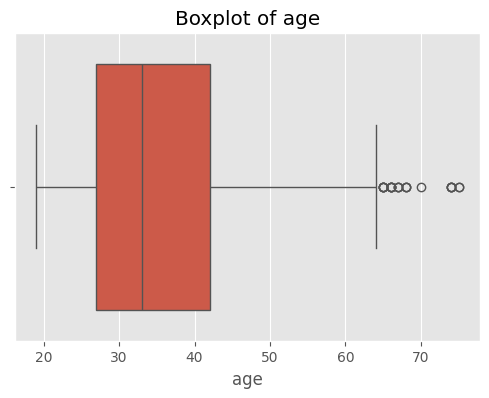

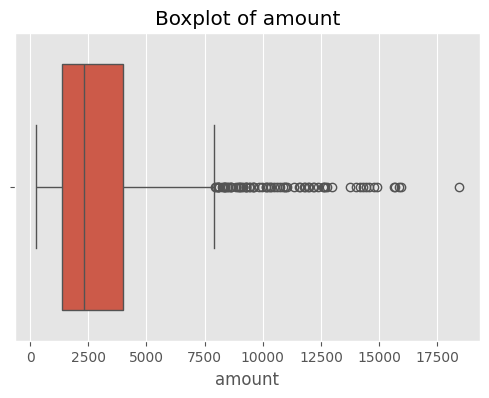

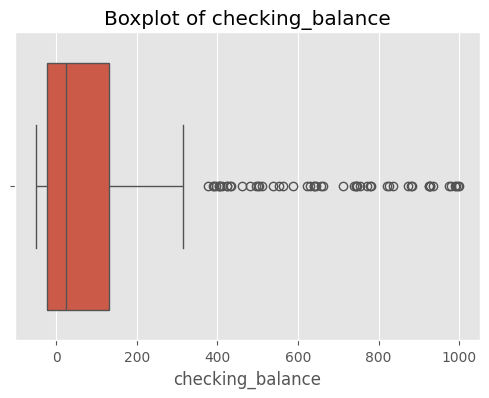

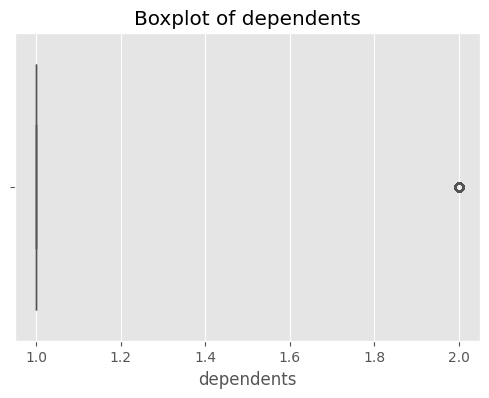

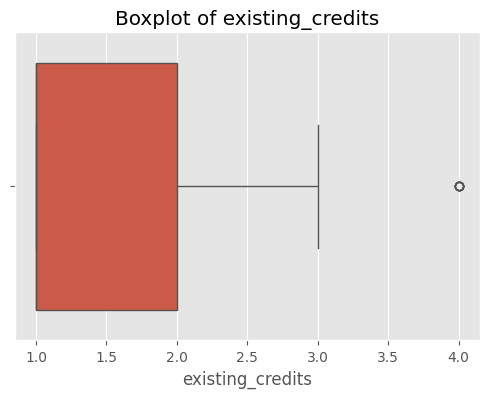

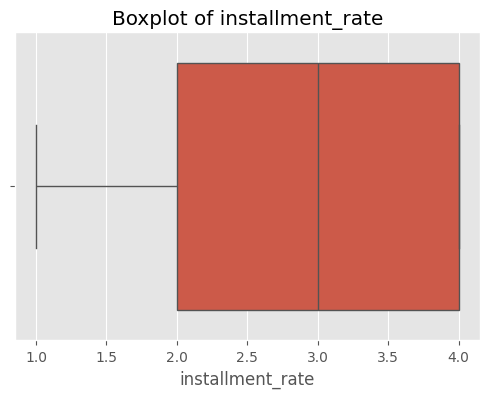

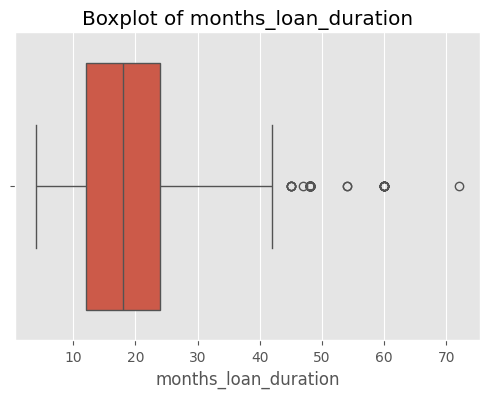

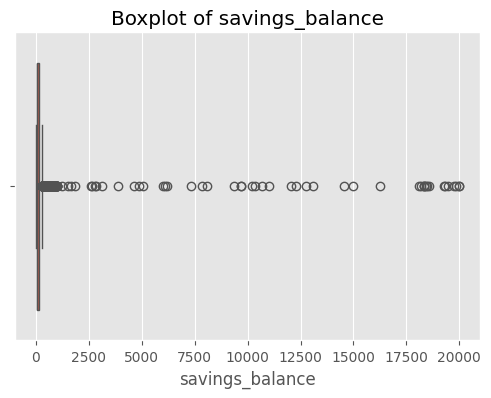

In [14]:
# Checking for outliers in the numeric features
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.difference(['telephone','default'])
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

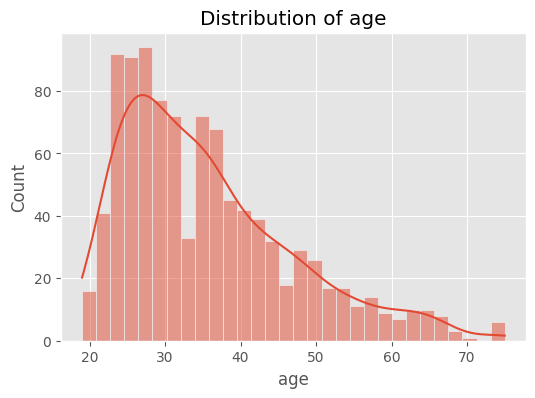

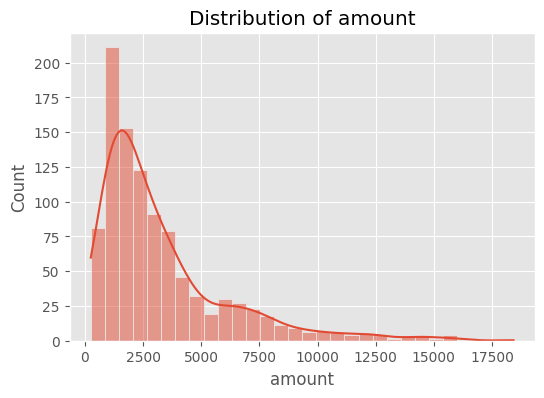

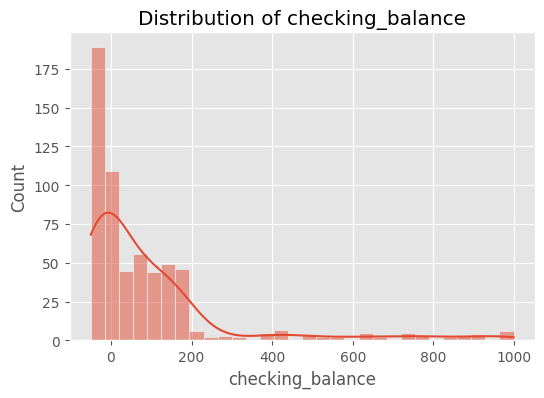

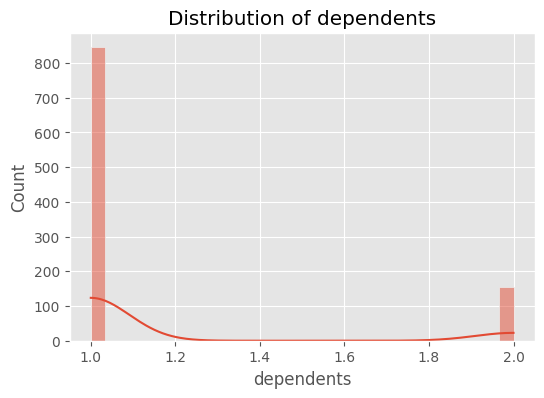

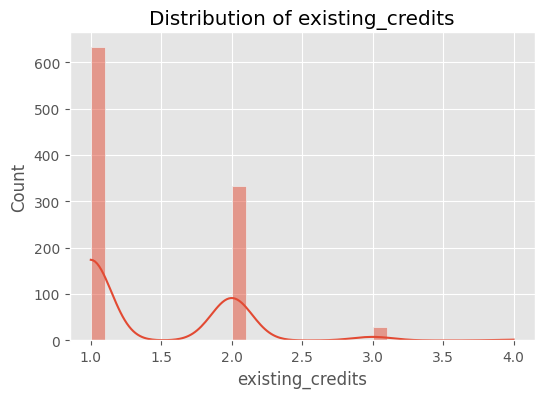

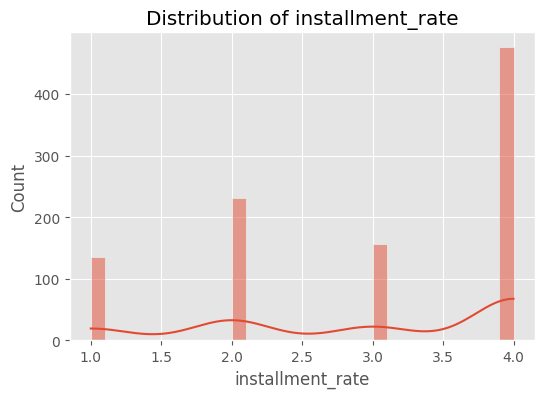

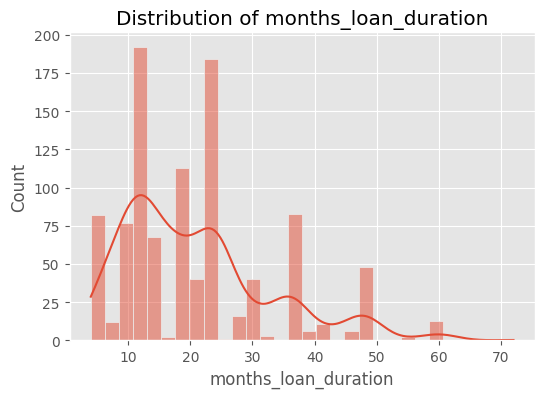

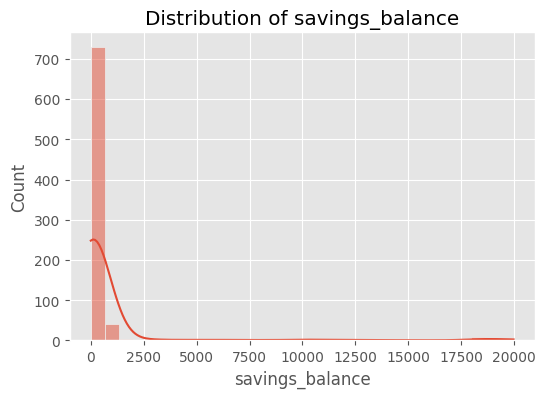

In [28]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

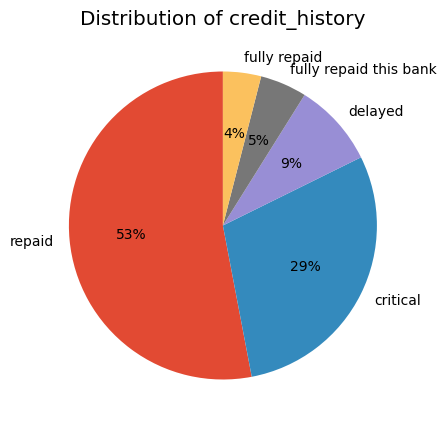

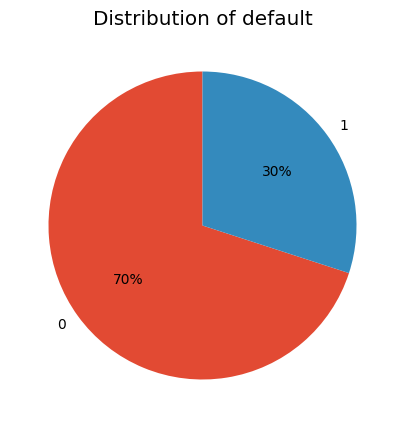

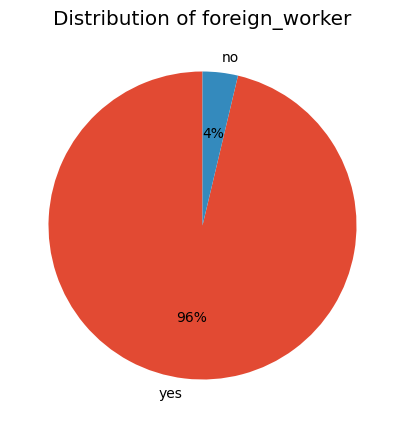

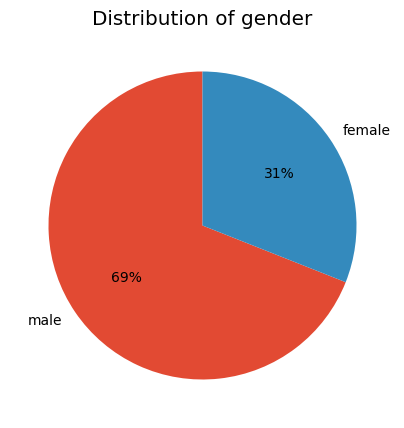

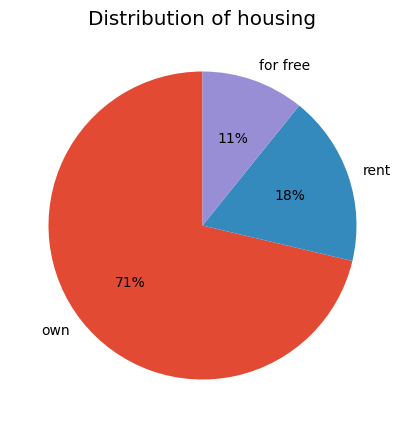

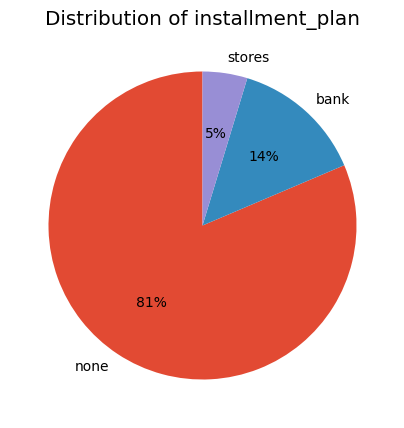

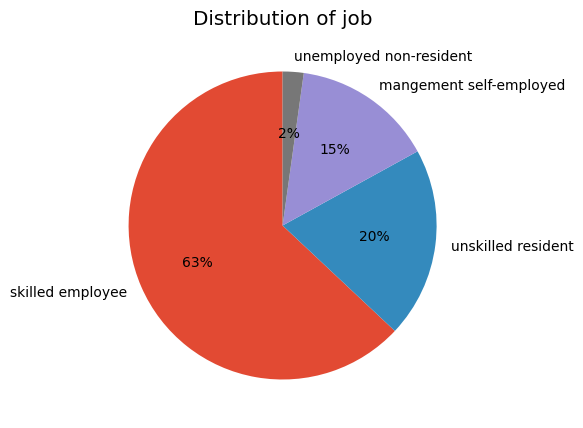

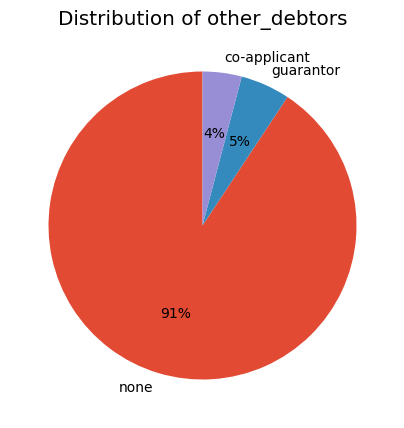

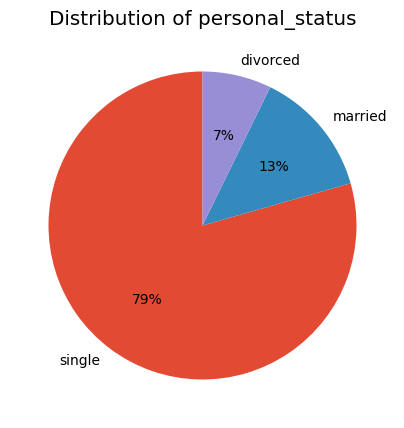

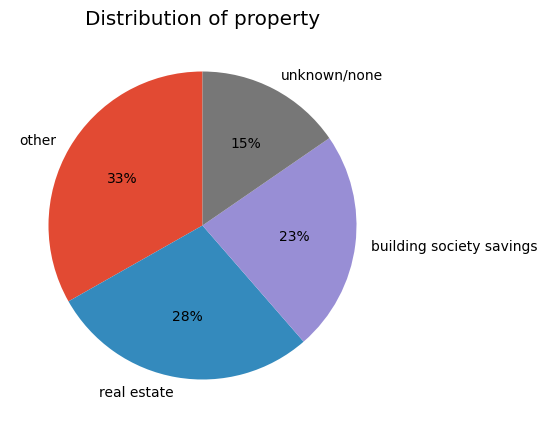

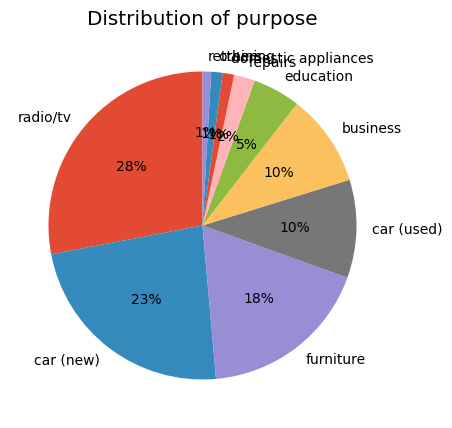

In [15]:
# Distibution plots for the features
# excluding residence_history and employment_length, as they have unusual number of categories
categorical_columns = (df.select_dtypes(include=['object', 'category']).columns
    .union([target_column])).difference(["employment_length","residence_history"])

for i in categorical_columns:
    df[i].value_counts().plot.pie(
        autopct="%1.0f%%",   # show percentages
        figsize=(5,5),    
        startangle=90       # rotate for better readability
    )
    plt.title(f"Distribution of {i}")
    plt.ylabel('')
    plt.show()

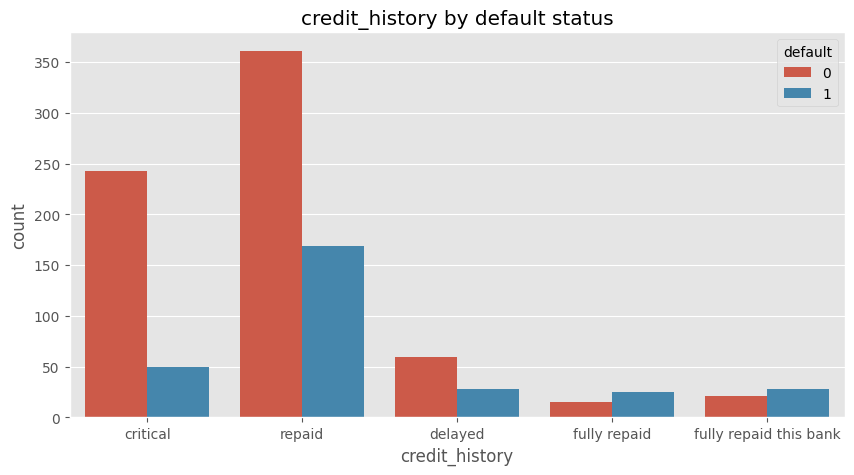

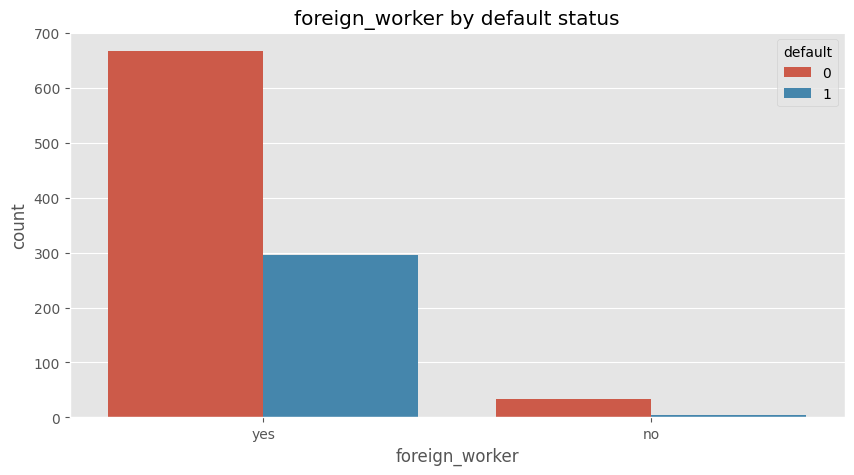

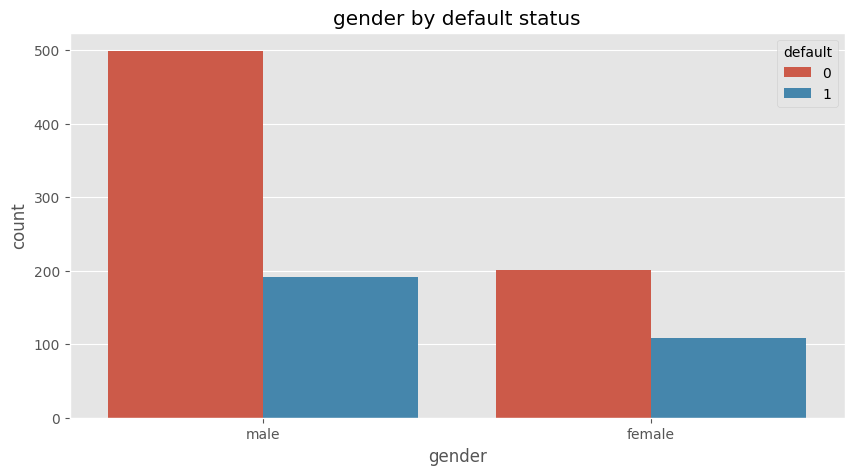

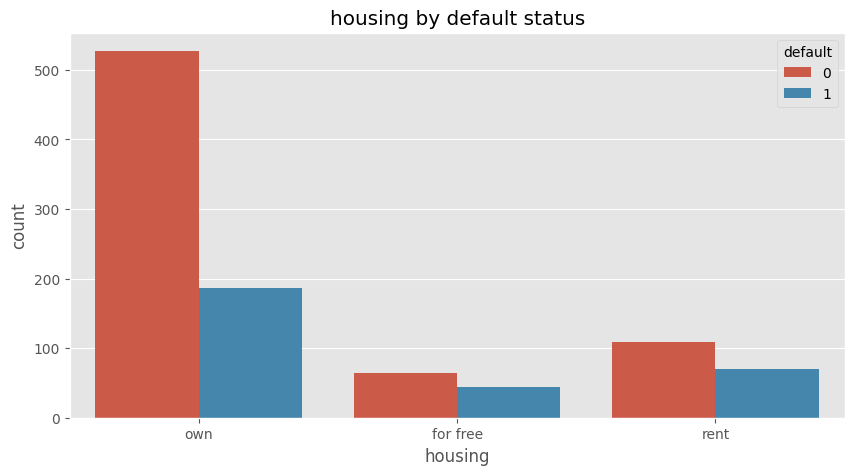

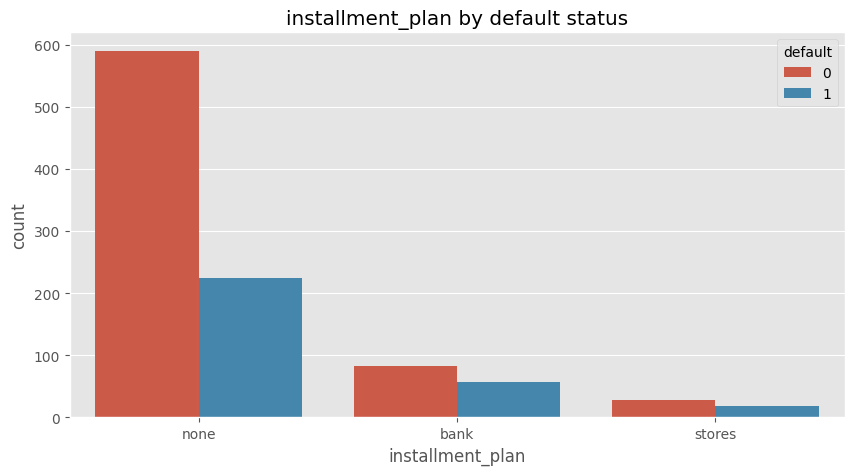

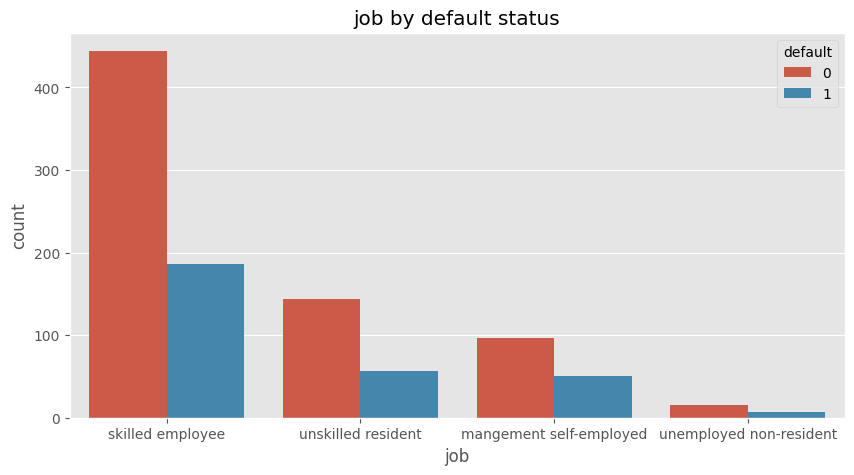

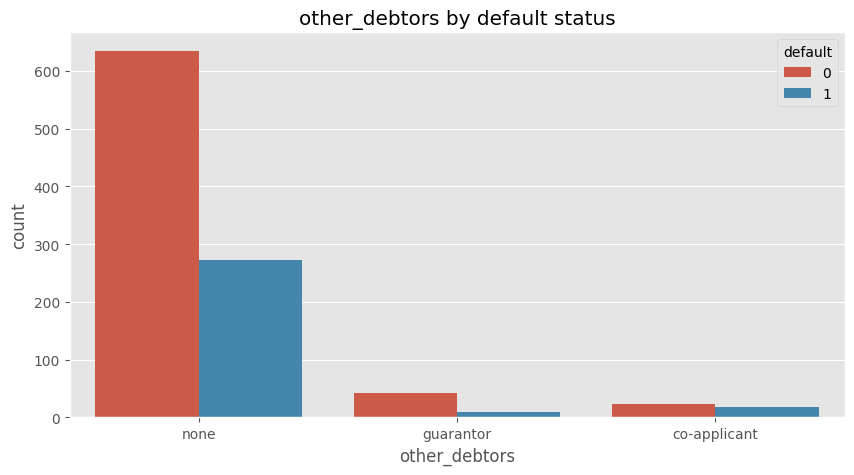

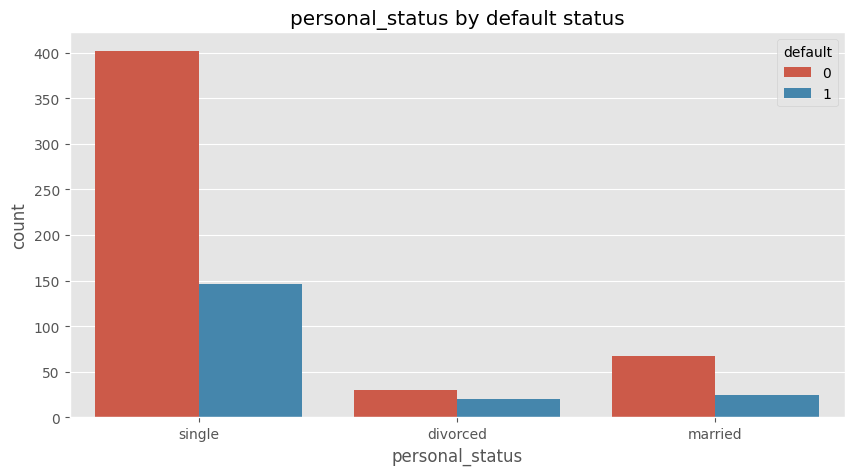

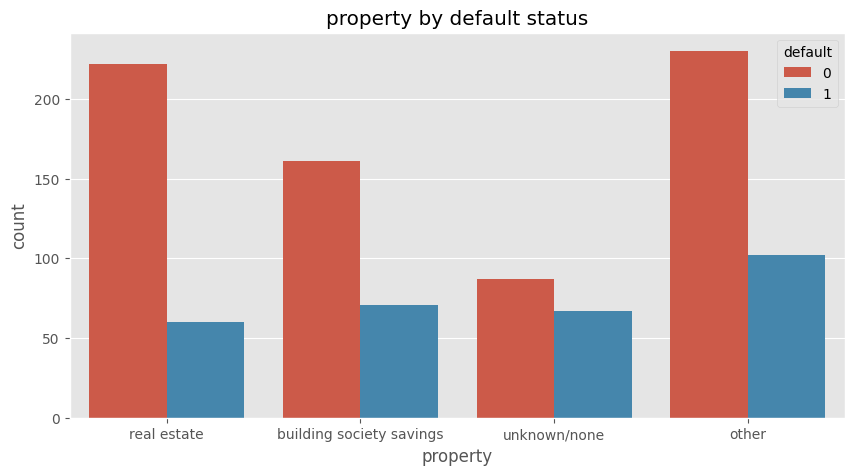

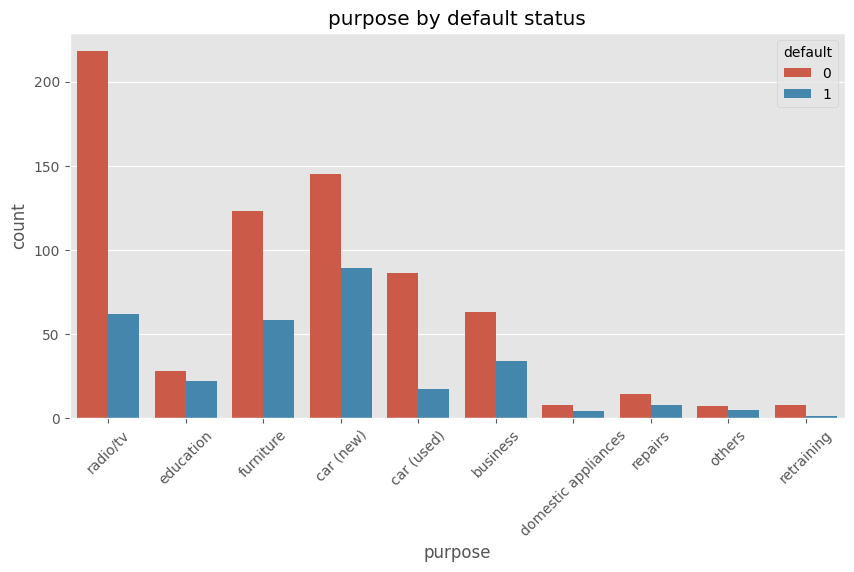

In [16]:
# obtain distribution plot for the categorical feautures against the target column 
categorical_columns = categorical_columns.difference([target_column])

# categoric features visualization
data_categoric = df.loc[:, categorical_columns]
for i in categorical_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(x = i, data = df, hue=target_column)
    plt.title(f"{i} by {target_column} status")
    if i == "purpose":
        plt.xticks(rotation=45)

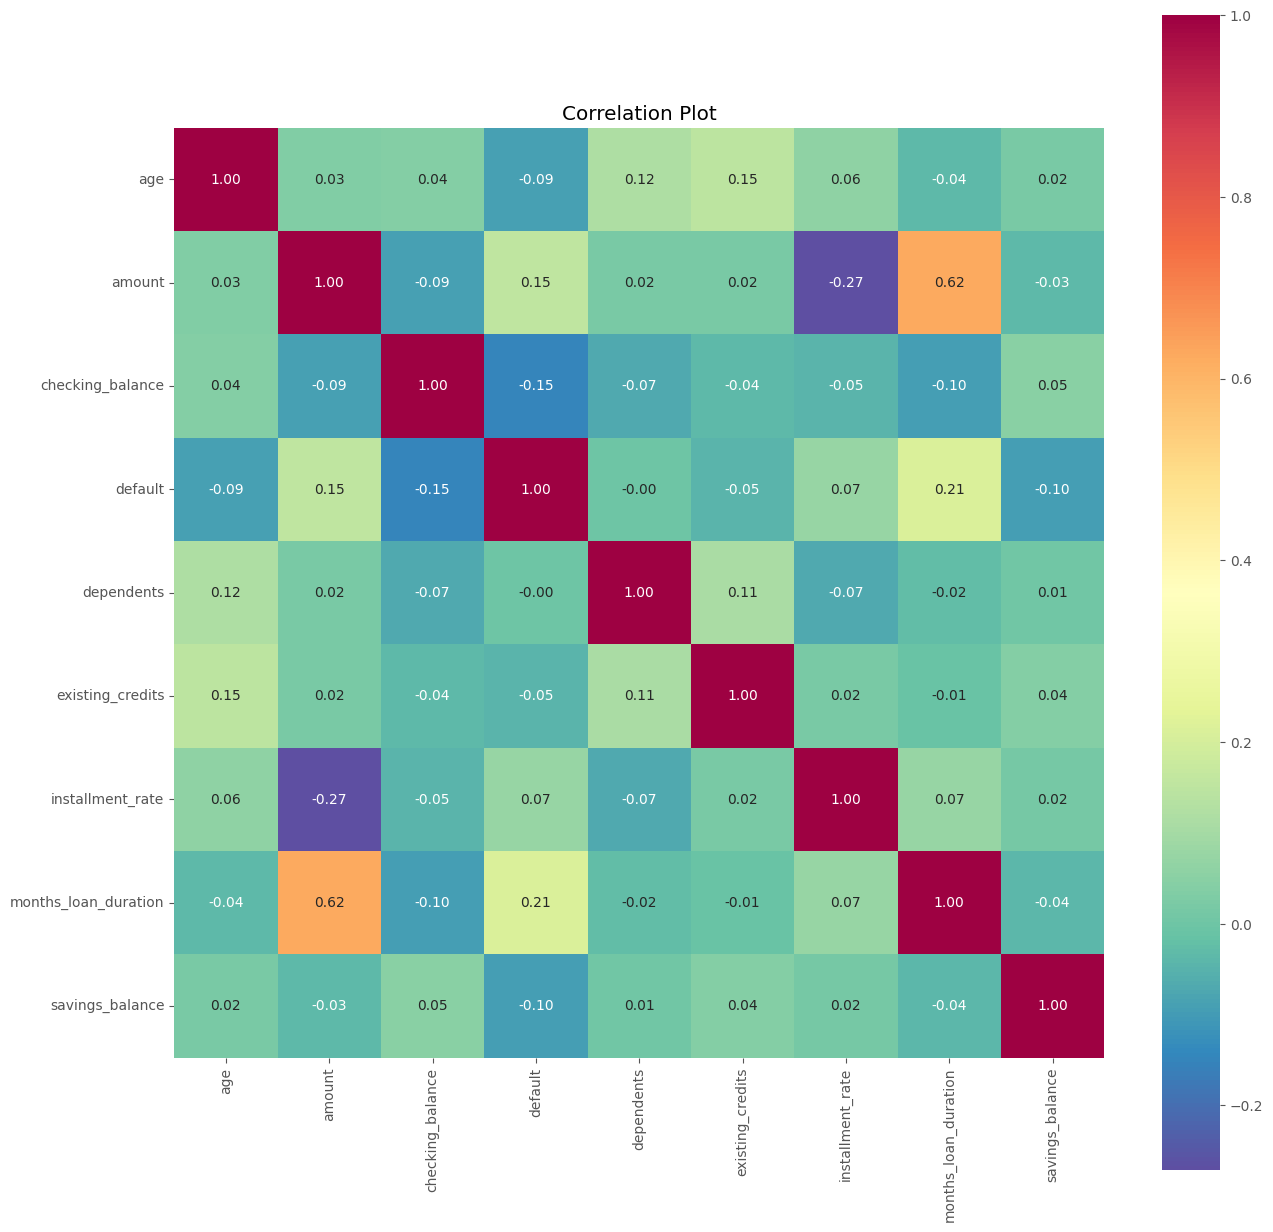

In [17]:
# Obtain Correlation matrix between the numeric features
cormat(df)

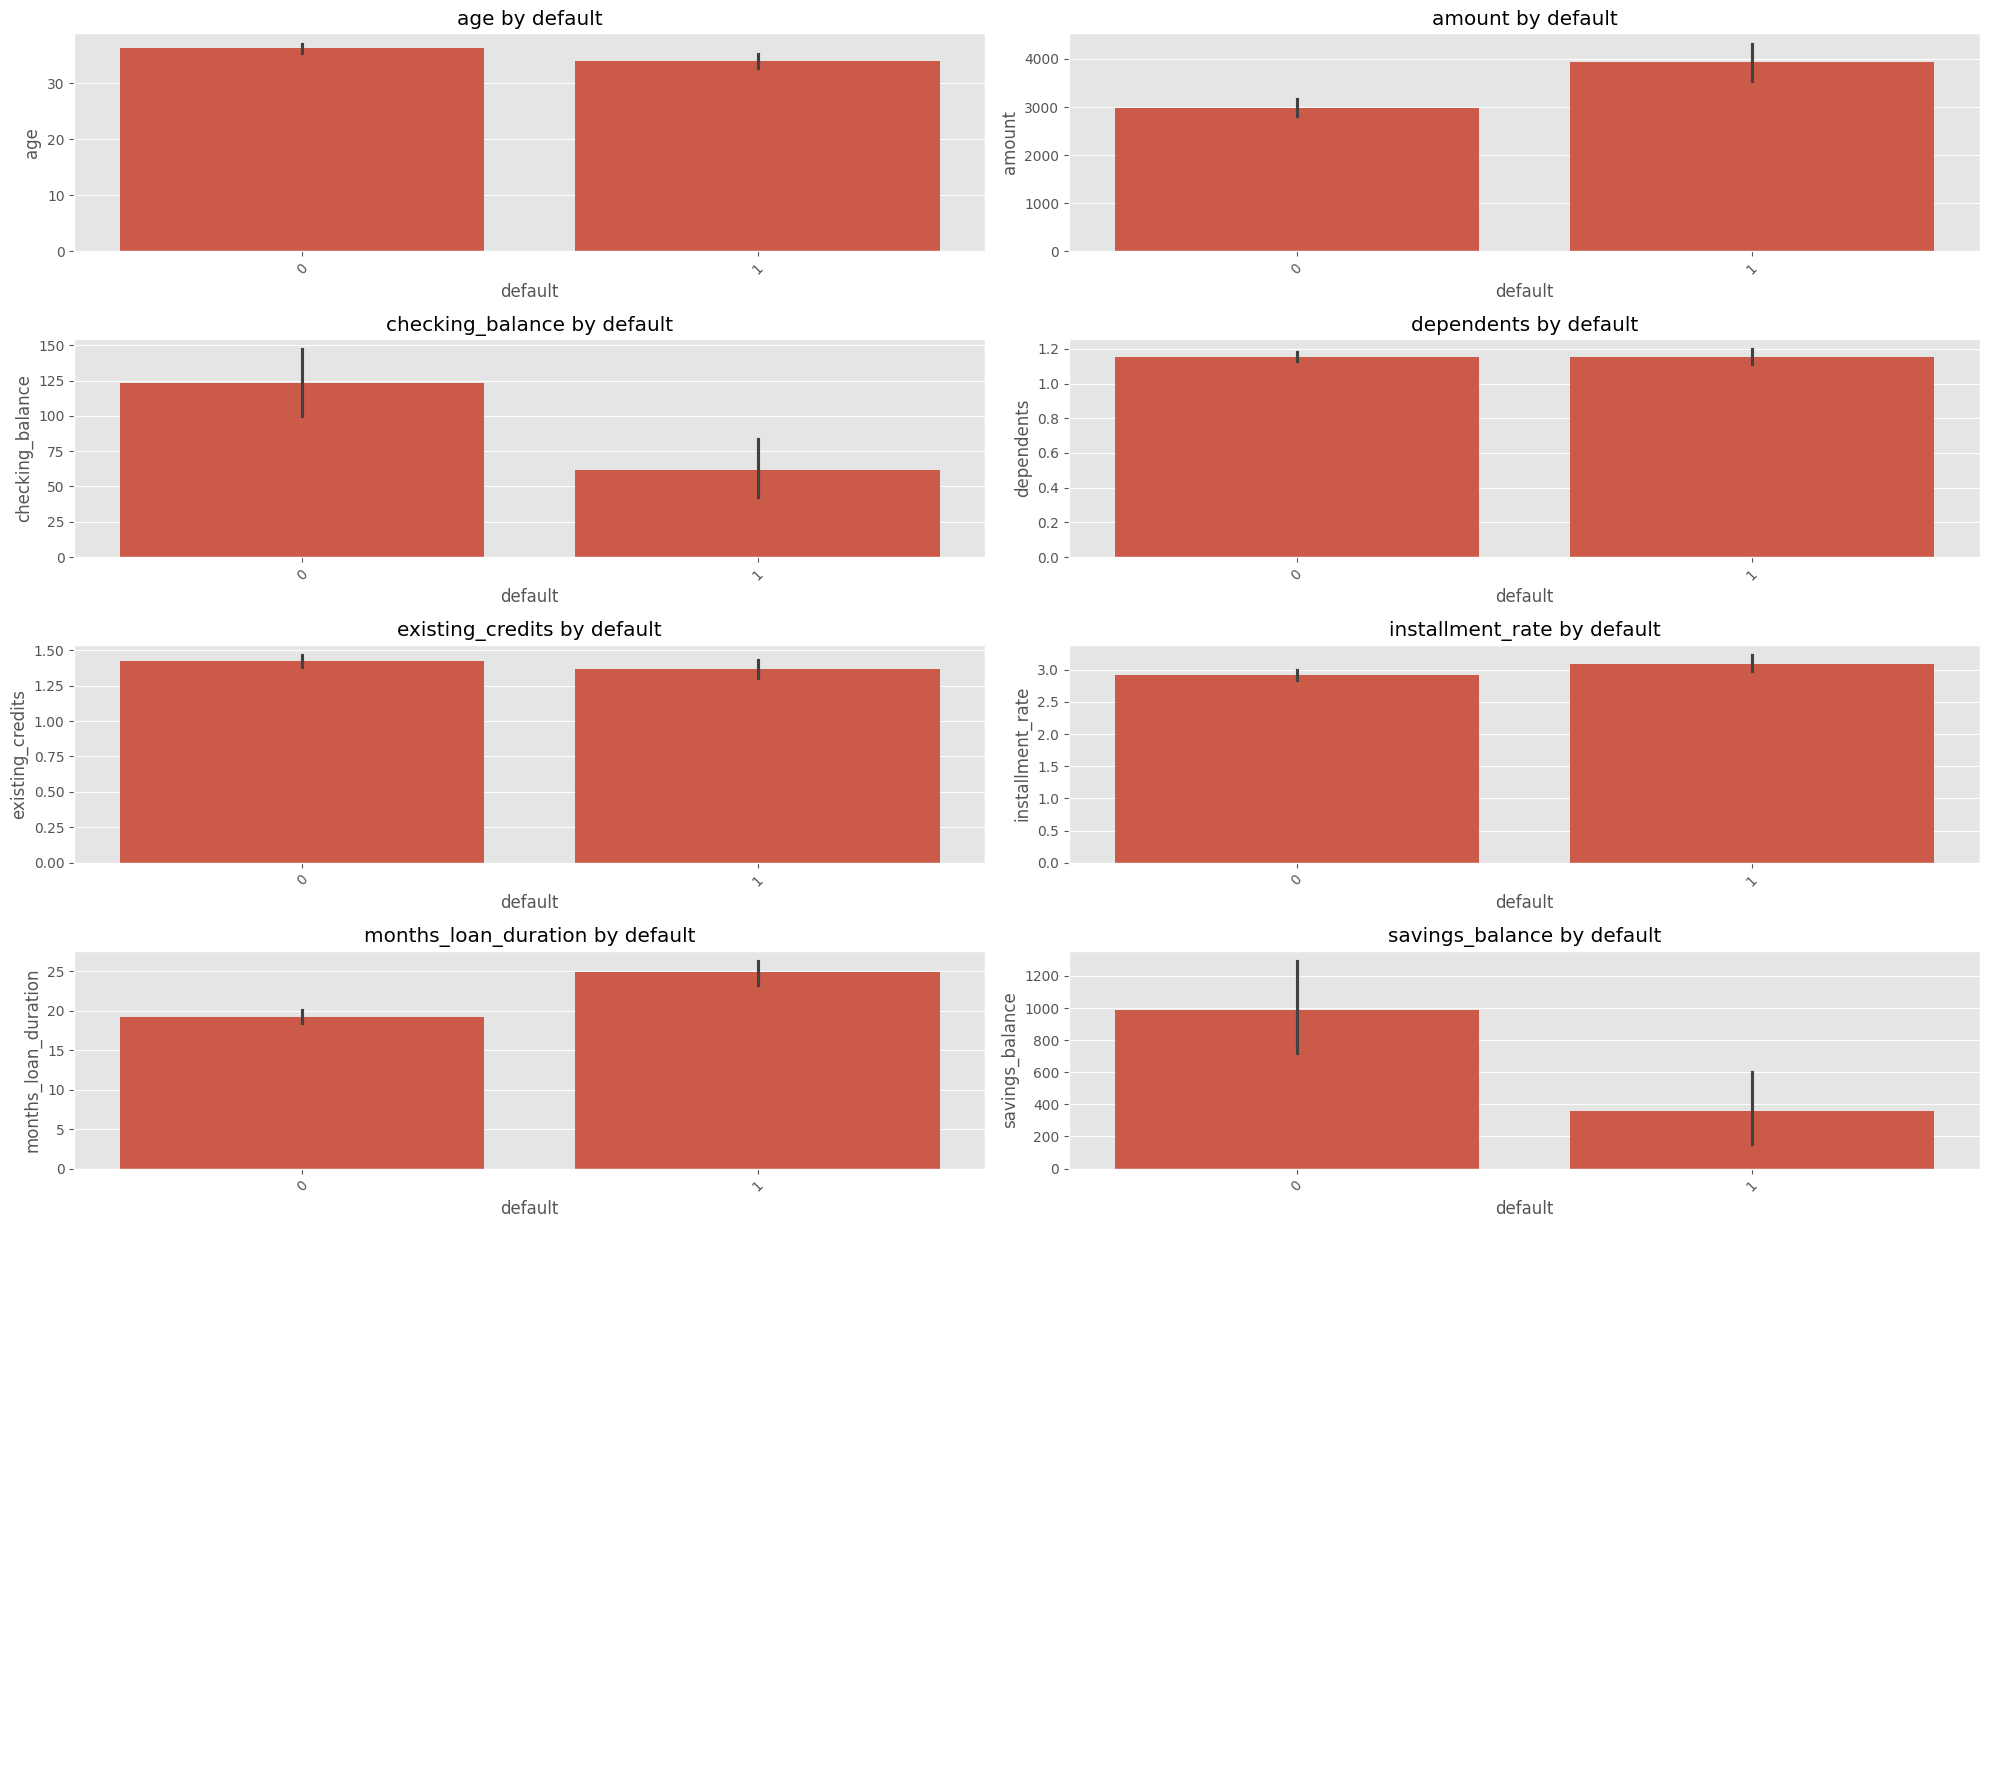

In [88]:
# Obtain distribution of the numeric features by the target 
barplot(target_column,df)

### Some Insights from the Dataset

* No duplicated records in the dataset
* Total records in the dataset is 1000, with 22 features.
* Features such as *checking_balance
savings_balance,employment_length,personal_status,residence_history,telephone* have missing records.
  - missingness in `checking_balance` could indicate `no checking account`
  - missing data in `savings_balance` could also indicate `no saving account`
  - missing data in `employment_length` could imply the person is `unemployed`.
  - someone without `residence_history` record could be new in the area.
  - missing record for `personal_status` could be due to its sensitivity.
  - missing `telephone` could imply no telephone is registered under the customer’s name"
* The credit history data showed that just 4% of these customers have fully repaid their previous loans with other banks, while 5% have fully repaid their previous loans with this bank. In addition, 29% have bad credit history, while 53% have existing loans being repaid as agreed, and 9% of these customers have records of delayed repayment.
* Defaulters in the dataset tend to have borrowed larger loan amounts on average compared to non-defaulters. This suggests that higher loan amounts may be associated with increased risk of default, although this effect could be influenced by other factors such as income and loan tenor.
* Both checking and savings balances exhibit similar patterns with respect to default risk. Customers with lower account balances are more likely to default, suggesting that limited liquidity and weaker financial buffers increase repayment risk.
* There are more than 2x males as compared to females in the dataset, which suggests a potential systematic bias towards females.
* In the dataset, bad credits tend to have longer tenors compared to good credits. This suggests that longer repayment durations may increase the risk of default, possibly due to higher uncertainty and repayment burden over time.
* There's no significant correlations among the numeric features, except between loan amount and tenor (r=0.62), which is understandable since borrowers taking larger loans tend to also take them over longer durations.
* `dependents` variable has zero correlation with the default variable, suggesting dependents variable is simply a noise feature.
* Outliers seem to be affecting the following features:`amount`, `checking_balance`,`savings_balance`
* **residence_history**, and **employment_length** have high number of categories.

### Strategies to Address Issues in the Dataset

* **Missing Records**: Missing values will be handled using a pipeline that integrates a `SimpleImputer` with a constant value, along with a corresponding missing-value flag for each feature. The flag serves as an additional signal to the model, capturing information that may be predictive of the target.
* **Imbalance dataset**: The dataset is moderately imbalanced, with 30% bad credits and 70% good credits. To address this and improve model generalization, the SMOTE (Synthetic Minority Over-sampling Technique) will be applied to create synthetic samples of the minority class.
* Fairly **strong correlation** between loan amount and tenor: Some tree-based models (RandomForest, XGBoost) will be considered during model training, since they are less sensitive to correlated features.
* **Exclusion of Sensitive/redundant features**:
    - `gender` will be excluded, it is a protected attribute in most jurisdictions and may introduce bias or discriminatory outcomes. Nevertheless, fairness assessment will be conducted to validate the model’s behavior with respect to gender attributes.
    - Additionally, `foreign_worker` provides little predictive value, as **96%** of the observations fall under the same category (foreigner).
    - `telephone` does not give any predictive information, and will also be excluded from the dataset.
    - `dependents` feature has zero correlation with the credit risk variable, making it a redundant variable in the dataset. This will also be dropped.
* **Outliers**: `RobustScaler` will be used to handle the outlying points gracefully, couple with the fact that tree-based models are robust to outliers.

**Note: Most of these strategies will be carried out during data preprocessing and model pipeline development** 



### Data Preprocessing

In this section, the following will be done
- The dataset will be split into training and testing datasets (using 80:20)
- Sensitive/redundant features (gender,telephone,foreign_worker,dependents,tenor) will be removed from the training and testing data

In [55]:
# Set the output folder for training and testing dataset, as well as the test dataset size
output_dir = "./processed_data"
test_size = 0.2

In [56]:
# The custom `preprocess_data` function achieve all of these at a go
preprocess_data(df, target_column, output_dir,test_size)

Datasets saved to ./processed_data


In [57]:
# Load the datasets
X_train = load_data("./processed_data/X_train.csv")
X_test = load_data("./processed_data/X_test.csv")

y_train = load_data("./processed_data/y_train.csv")
y_test = load_data("./processed_data/y_test.csv")

protected_feature_train = load_data("./processed_data/protected_train.csv")
protected_feature_test = load_data("./processed_data/protected_test.csv")

In [58]:
# Check the datasets
X_train.shape, X_test.shape

((800, 17), (200, 17))

In [59]:
y_train.shape, y_test.shape

((800, 1), (200, 1))

In [60]:
protected_feature_train.shape, protected_feature_test.shape

((800, 1), (200, 1))

### Model Development

In this section, a unified pipeline that will handle the following was developed.

* **Features Engineering**
   * Introduce flags for missing data
   * Derive new features: `total_balance`,`loan_to_balance`,`age_bucket`,`loan_amount_bucket`,`credit_history_severity`.
   * Interactive Features: `employment_x_amount`,`balance_x_savings`
* **Missing data** - computed using `SimpleImputer` (**most frequency** for categorical, **constant=0** for numerics) 
* **Dataset imbalance**: addressed using SMOTE to generate synthetic samples for the minority class ("bad" credit risk) during model training.
* **Data Normalization**
  - Standardization for numerics
  - OneHotEncoding for categorical variables
* **Model training & Evaluation**
  - Trained four models Random Forest, XGBoost, KNN, Logistic Regression
  - Handled **overfitting** based on Feature importance selection
  - Evalaute model performance on test datasets

In [61]:
# Train all the models using the pre-defined pipeline, and return the performance metrics
train_and_evaluate_model(X_train, X_test, y_train, y_test)

Model: LogisticR
Test dataset performance
Accuracy: 0.65
Precision: 0.44
Recall: 0.64
F1 Score: 0.52
ROC AUC: 0.67


Training dataset performance
Accuracy: 0.73
Precision: 0.53
Recall: 0.72
F1 Score: 0.61
ROC AUC: 0.81


Model: RandomForest
Test dataset performance
Accuracy: 0.72
Precision: 0.55
Recall: 0.56
F1 Score: 0.55
ROC AUC: 0.75


Training dataset performance
Accuracy: 0.78
Precision: 0.63
Recall: 0.63
F1 Score: 0.63
ROC AUC: 0.86


Model: XGBoost
Test dataset performance
Accuracy: 0.70
Precision: 0.51
Recall: 0.66
F1 Score: 0.57
ROC AUC: 0.74


Training dataset performance
Accuracy: 0.79
Precision: 0.63
Recall: 0.69
F1 Score: 0.66
ROC AUC: 0.87


Model: KNN
Test dataset performance
Accuracy: 0.59
Precision: 0.41
Recall: 0.74
F1 Score: 0.52
ROC AUC: 0.66


Training dataset performance
Accuracy: 0.76
Precision: 0.57
Recall: 0.90
F1 Score: 0.69
ROC AUC: 0.90




#### Interpretation
* Logistic regression is decent at detecting defaults (recall), but many predictions are false positives (low precision).
* Random Forest is very conservative: it predicts defaults accurately with moderate precision but misses a lot of actual defaults (low recall)
* XGBoost performance is similar to Random Forest, however it slightly edges Random Forest in terms of accuracy and recall.
* KNN predicts many defaults (high recall), but it has low precision, causing many false alarms. And it seems to be suffering from overfitting.

### Model Evaluation

Here we will look at the four models from holistic points of view, using only the testing dataset

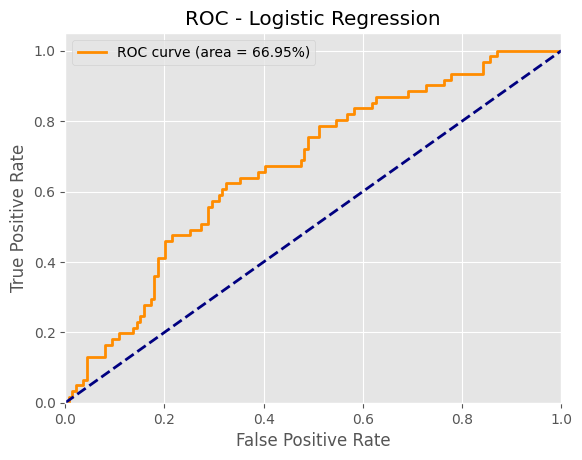

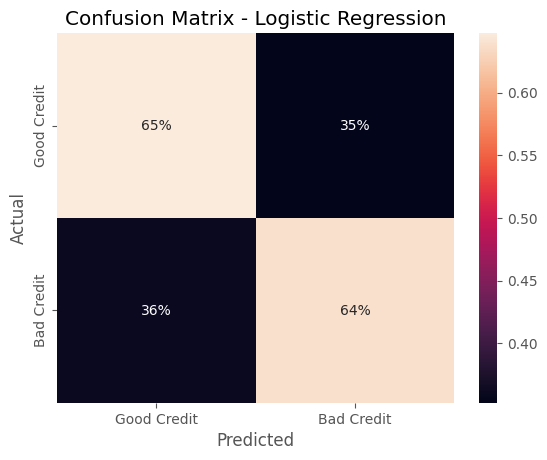

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.80      0.65      0.72       139
           1       0.44      0.64      0.52        61

    accuracy                           0.65       200
   macro avg       0.62      0.64      0.62       200
weighted avg       0.69      0.65      0.66       200



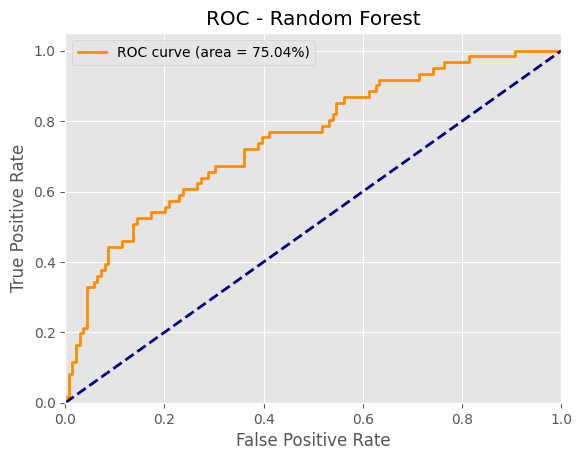

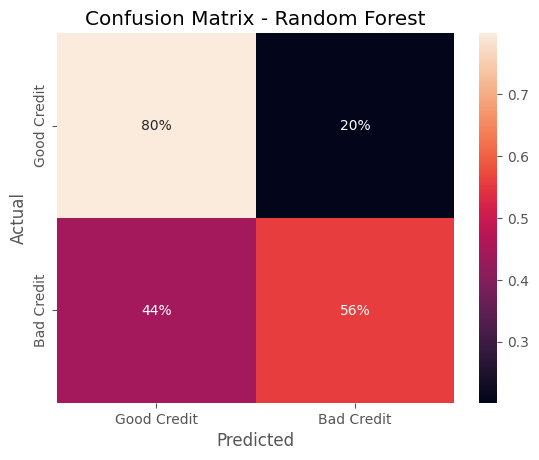

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.80      0.80      0.80       139
           1       0.55      0.56      0.55        61

    accuracy                           0.72       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.73      0.72      0.73       200



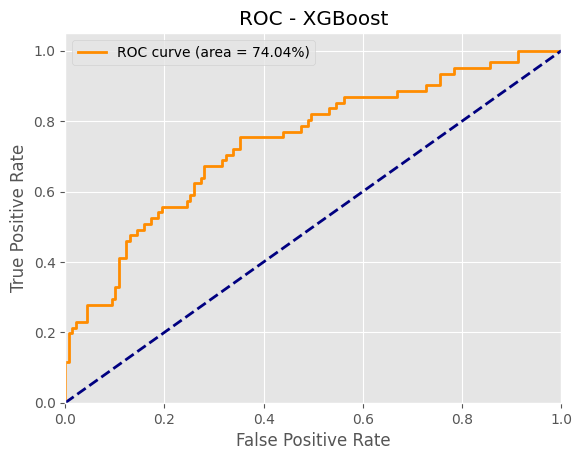

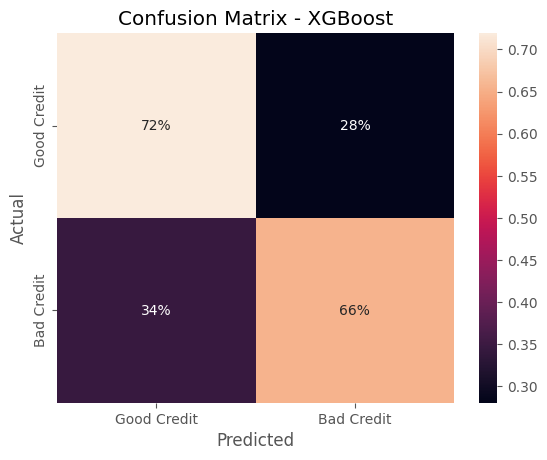

Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.83      0.72      0.77       139
           1       0.51      0.66      0.57        61

    accuracy                           0.70       200
   macro avg       0.67      0.69      0.67       200
weighted avg       0.73      0.70      0.71       200



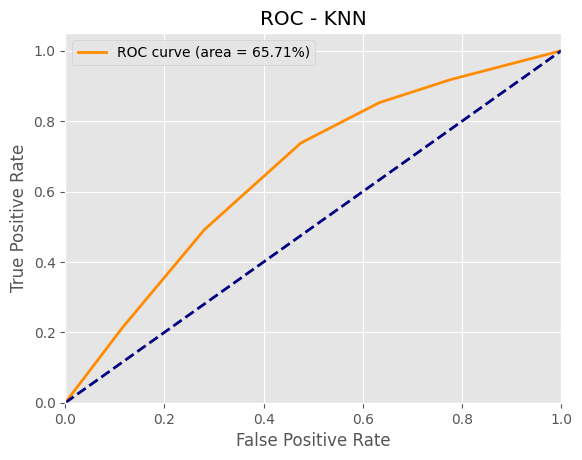

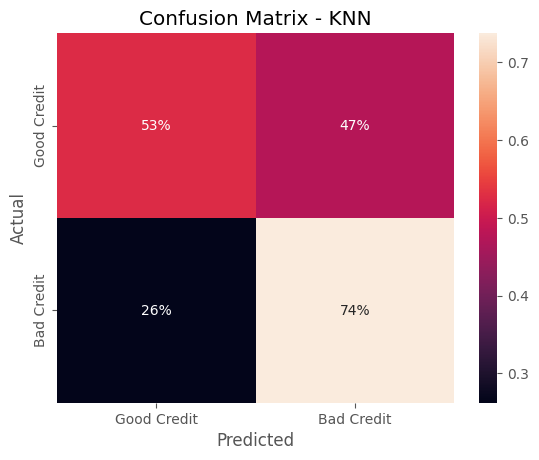

Classification Report for KNN:

              precision    recall  f1-score   support

           0       0.82      0.53      0.64       139
           1       0.41      0.74      0.52        61

    accuracy                           0.59       200
   macro avg       0.61      0.63      0.58       200
weighted avg       0.69      0.59      0.60       200



In [62]:
# This returns the evalutions metrics such as ROC curve, Confusion matrix etc
evaluate_model(X_test, y_test)

**Interpretation**

From the results above, we can see that the four models perform better at predicting good credit than bad credit.

For instance, Random Forest was 87%  precise when predicting good credit. In terms of recall, 82% of actual good credit cases were correctly identified. However, for instances predicted as bad credit, the model’s performance is lower: precision is 63%, indicating that only 63% of predicted bad credits were actually bad. However, the recall is 72%, showing that 72% of actual bad credit cases were successfully identified.

Even though SMOTE was applied during training (via the pipeline), so the model has balanced class exposure while learning, the models still struggle with the minority class (bad credit). This is expected since the training size is small, and also this could be because the features for bad credit are less distinctive.

Next, we will cross-validate the models, to stabilize their hyper-parameters and improve their ability to generalize to unseen data.


### Model Validation

Here we will use 5-fold stratified sampling to get more reliable metrics rather than relying on a single training/testing split, to assess generalization of the models. 

This step will help us determine the best model of all the four, which we will then work with for further analysis

In [63]:
# Cross_validate the models, and return the best among the four models
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=24)
scoring = {
    "roc_auc": "roc_auc",
    "recall": "recall",
    "f1": "f1",
    "balanced_acc": "balanced_accuracy"
}

model_val(X_train,y_train,cv,scoring)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Logistic Regression: 0.5305291701684545
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Random Forest: 0.5484953577225522
Fitting 5 folds for each of 50 candidates, totalling 250 fits
XGBoost: 0.5680051968042072
Fitting 5 folds for each of 50 candidates, totalling 250 fits
KNN: 0.505088561997293

Best Model: XGBoost | Score: 0.5680051968042072


### Best Model Performance

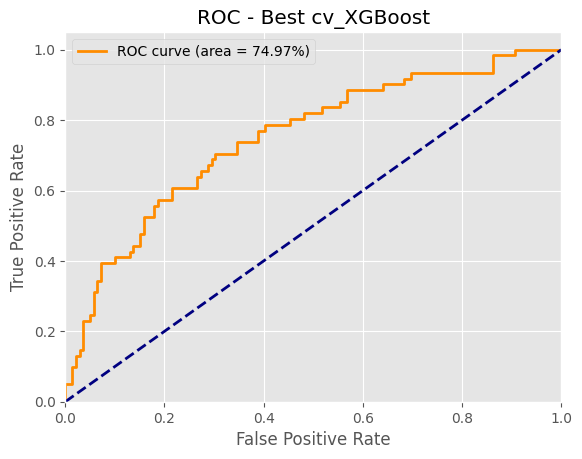

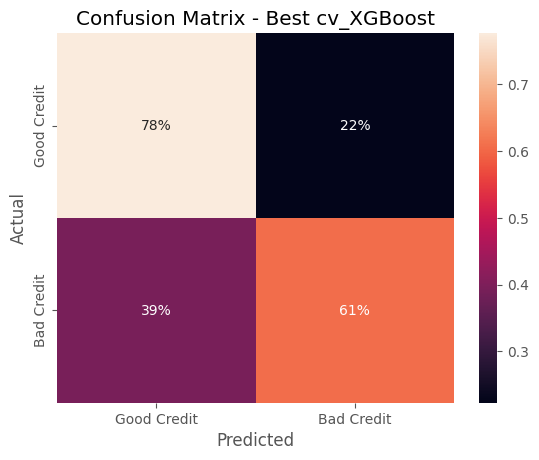

Best Model Performance Report
{'accuracy': [0.725], 'precision': [0.5441176470588235], 'recall': [0.6065573770491803], 'f1_score': [0.5736434108527132], 'roc_auc': [0.7497346385186933]}
Kindly check './report' for the reports


In [64]:
# This function only takes in X_test and y_test, it will find the best model and return its performance
best_model_report(X_test,y_test)

The above shows that the best model correctly predicts 72% overall, and the model correctly identifies about 61% of bad credit risk.


Next, we will look at the importance of the features in the dataset to predicting defaulting behaviour, as well as the direction of their effects on credit risk prediction.

### Feature Importance

We will measure the importance of the features in the model on predicting credit risk

1. We will use feature importance method of `Random Forest` to check the most/least contributing features
2. We will then use SHAP explainer to determine the direction of this effect

In [65]:
# load the best model
_, model_path = find_best()
pipeline = load_model(model_path)

In [66]:
# Get transformed feature names
feature_names = pipeline[:-1].get_feature_names_out()

# Now align importances
model = pipeline.named_steps['classifier']   # obtain the model object from the pipeline

# store the importances in a dataframe
importances = pd.Series(model.feature_importances_, index=feature_names)

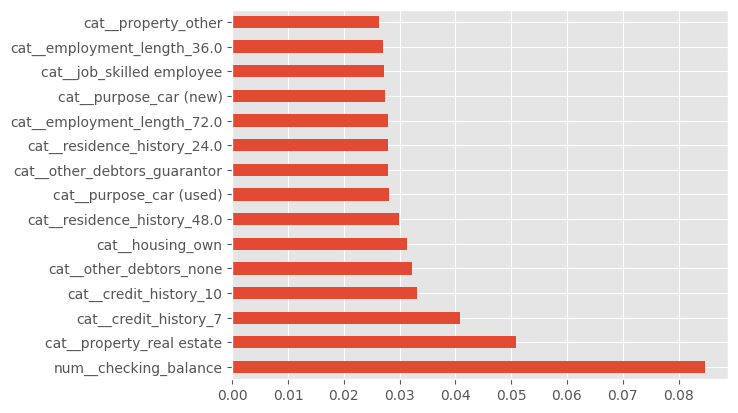

In [67]:
#plot the importance of the most contributing features
importances.nlargest(15).plot(kind='barh')
plt.show()

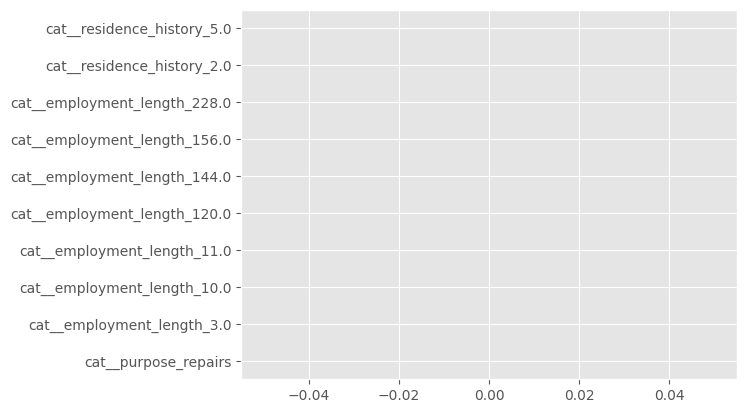

In [68]:
#plot the importance of the least contributing features
importances.nsmallest(10).plot(kind='barh')
plt.show()

In [69]:
# Create explainer the model
explainer = shap.TreeExplainer(model)

# Transform test features (exclude classifier in pipeline)
X_transformed = pipeline[:-1].transform(X_test)

# Compute SHAP values
shap_values = explainer(X_transformed)

In [72]:
shap_values.shape

(200, 64)

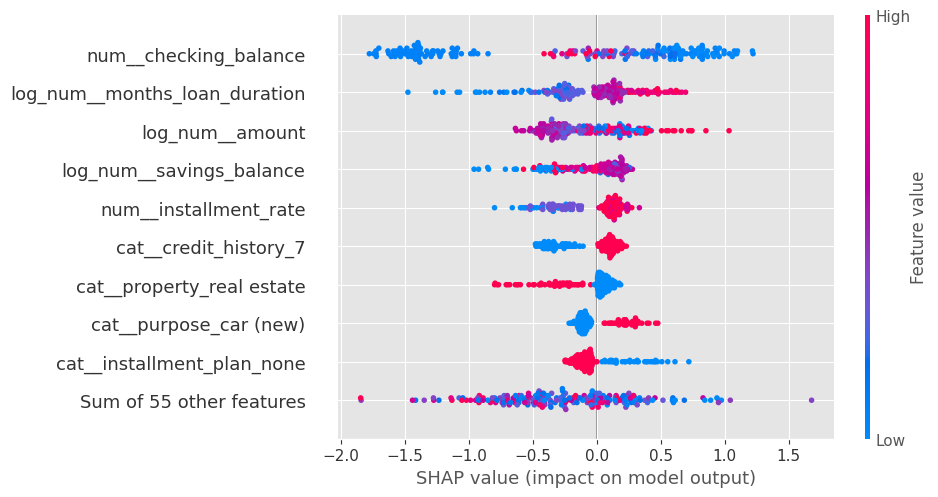

In [73]:
#shap_values_class1 = shap_values[:, :, 1]
shap.plots.beeswarm(shap_values)

### Interpretation

The results from above suggest:
* Checking balance, loan tenor,loan amount,savings balance, installment rate,and credit history are the most influential factors in predicting credit risk.
* Higher values for checking balance, installment rate, loan tenor, loan amount increase default risk

### Fairness Check

Here we will do fairness check for gender to ascertain, model fairness irrespective of gender category 

In [74]:
# First obtain prediction for testing datasete using the best model
y_pred = pipeline.predict(X_test)

In [75]:
# Fairness Check for gender
sensitive = protected_feature_test["gender"]

In [76]:
fairness_check(y_test,y_pred,sensitive)

Performance by group:
         accuracy  selection_rate       tpr
gender                                    
female  0.757576        0.348485  0.652174
male    0.708955        0.335821  0.578947
Demographic parity difference: 0.012663952962460423
Demographic parity ratio: 0.963659961064244
Equalized odds difference: 0.07322654462242562


### Interpretation

The above results impliy that the model is legally and statistically safe.

The accuracy is similar across the two groups. The model correctly predict the likelihood of a loan with 69% accuracy for female customers, and 71% for their male counterpart.

Selections rate are nearly the same as well. Females (34.8%) are approved slightly more often than males (33.6%).

Among actually good customers, females are approved 65% of the time, while 58% of the time for their males counterpart.

### Conclusion

In this analysis, we employed various machine learning models to predict credit risk based on the German Credit Risk dataset.

The results from this analysis shows that Checking balance, loan tenor,loan amount,savings balance, installment rate,customer's age, number of existing loans and credit history are the most influential factors in predicting credit risk

Although our models achieved decent accuracy rates: Logistic Regression at 70%, Random Forest at 80%, and XGBoost at 79%, KNN at 65%, they demonstrated challenges in accurately predicting "bad" credit risks. The F1 score for these models provided justification to identifying the best performing model in balancing recall and precision .After cross-validating all the models, XGBoost came out as the best performing with F1 score at 57%, accuracy at 71% and recall at 77%. 

Further analysis showed that implementing techniques such as SMOTE and using a balanced Random Forest improved the model's ability to identify "bad" risks but did not significantly enhance overall accuracy. This is so because synthetic samples only help learning patterns but cannot fully replace real-world diversity. For future improvement, we can increase the training dataset or adding new features such as payment behaviour, occupation stability etc to improve this performance

Furthermore, gender was used to assess the fairness of the model in predicting credit risk for males and females. The results showed that the model is formally fair in outcomes, and also fair in error distribution. The results showed that in practice, women with the same repayment ability as men will be likely to be correctly approved as men.
